# Lumbar MRI Classification — Rewritten Training Pipeline

This notebook rewrites the baseline into a cleaner end-to-end pipeline for **slice-based lumbar spine MRI classification** with:

- **1-channel MRI input** instead of fake RGB duplication
- **MRI-safe augmentation**
- **class imbalance handling** via weighted sampler and optional weighted CE / focal loss
- **label smoothing**
- **early stopping**
- **better metrics**: macro F1, balanced accuracy, per-class report, confusion matrix
- optional **MixUp**
- configurable **frozen / full fine-tuning**

Update `DATA_ROOT` below to your local dataset path.

In [1]:
# =========================
# 1) Imports
# =========================
import os
import re
import copy
import time
import math
import random
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# =========================
# 2) Reproducibility
# =========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

In [3]:
# =========================
# 3) Config
# =========================
@dataclass
class CFG:
    # ---- paths ----
    DATA_ROOT: str = "/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-classification"
    TRAIN_DIR_NAME: str = "train"
    TEST_DIR_NAME: str = "test"

    # ---- image ----
    IMAGE_SIZE: int = 224
    RESIZE_SIZE: int = 256
    IN_CHANNELS: int = 1

    # ---- training ----
    BATCH_SIZE: int = 32
    NUM_WORKERS: int = 2
    EPOCHS: int = 30
    LR: float = 3e-4
    WEIGHT_DECAY: float = 1e-4
    PATIENCE: int = 5
    AMP: bool = True
    FREEZE_BACKBONE_EPOCHS: int = 0  # set >0 if you want warmup with frozen backbone

    # ---- split ----
    TRAIN_RATIO: float = 0.80
    GAP: int = 10   # same idea as your blocked split; removes a buffer around split boundary

    # ---- imbalance ----
    USE_WEIGHTED_SAMPLER: bool = True
    LOSS_NAME: str = "ce"  # "ce" or "focal"
    USE_CLASS_WEIGHTS_IN_LOSS: bool = False
    LABEL_SMOOTHING: float = 0.05

    # ---- augment ----
    USE_MIXUP: bool = False
    MIXUP_ALPHA: float = 0.2
    RANDOM_ERASE_P: float = 0.10

    # ---- optimization ----
    MODEL_NAME: str = "resnet34"
    PRETRAINED: bool = True

    # ---- normalization ----
    # Replace with train-set-only estimates if you recompute them
    MEAN: float = 0.1669754
    STD: float = 0.2372296

    # ---- output ----
    SAVE_DIR: str = "./outputs_lumbar_resnet34"
    BEST_MODEL_NAME: str = "best_model.pth"

cfg = CFG()
os.makedirs(cfg.SAVE_DIR, exist_ok=True)
print(asdict(cfg))

{'DATA_ROOT': '/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-classification', 'TRAIN_DIR_NAME': 'train', 'TEST_DIR_NAME': 'test', 'IMAGE_SIZE': 224, 'RESIZE_SIZE': 256, 'IN_CHANNELS': 1, 'BATCH_SIZE': 32, 'NUM_WORKERS': 2, 'EPOCHS': 30, 'LR': 0.0003, 'WEIGHT_DECAY': 0.0001, 'PATIENCE': 5, 'AMP': True, 'FREEZE_BACKBONE_EPOCHS': 0, 'TRAIN_RATIO': 0.8, 'GAP': 10, 'USE_WEIGHTED_SAMPLER': True, 'LOSS_NAME': 'ce', 'USE_CLASS_WEIGHTS_IN_LOSS': False, 'LABEL_SMOOTHING': 0.05, 'USE_MIXUP': False, 'MIXUP_ALPHA': 0.2, 'RANDOM_ERASE_P': 0.1, 'MODEL_NAME': 'resnet34', 'PRETRAINED': True, 'MEAN': 0.1669754, 'STD': 0.2372296, 'SAVE_DIR': './outputs_lumbar_resnet34', 'BEST_MODEL_NAME': 'best_model.pth'}


In [4]:
# =========================
# 4) Paths and metadata
# =========================
TRAIN_DIR = Path(cfg.DATA_ROOT) / cfg.TRAIN_DIR_NAME
TEST_DIR = Path(cfg.DATA_ROOT) / cfg.TEST_DIR_NAME

assert TRAIN_DIR.exists(), f"Train dir not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Test dir not found: {TEST_DIR}"

def extract_num(fname: str):
    m = re.search(r"image_(\d+)\.jpg$", fname)
    return int(m.group(1)) if m else None

def collect_records(split_dir: Path):
    records = []
    for cls in sorted(os.listdir(split_dir)):
        cls_path = split_dir / cls
        if not cls_path.is_dir():
            continue
        for fname in sorted(os.listdir(cls_path)):
            if not fname.lower().endswith(".jpg"):
                continue
            num_id = extract_num(fname)
            if num_id is None:
                continue
            records.append({
                "path": str(cls_path / fname),
                "label": cls,
                "filename": fname,
                "num_id": num_id,
            })
    df = pd.DataFrame(records)
    class_names = sorted(df["label"].unique())
    label2id = {label: i for i, label in enumerate(class_names)}
    id2label = {i: label for label, i in label2id.items()}
    df["label_id"] = df["label"].map(label2id)
    return df, class_names, label2id, id2label

full_train_df, CLASS_NAMES, label2id, id2label = collect_records(TRAIN_DIR)
test_df, _, _, _ = collect_records(TEST_DIR)

print("Classes:", CLASS_NAMES)
print("\nTrain class counts:")
print(full_train_df["label"].value_counts())
print("\nTest class counts:")
print(test_df["label"].value_counts())

Classes: ['Herniated Disc', 'No Stenosis', 'Thecal Sac']

Train class counts:
label
Thecal Sac        4733
No Stenosis       3152
Herniated Disc    3063
Name: count, dtype: int64

Test class counts:
label
No Stenosis       1507
Herniated Disc    1218
Thecal Sac          13
Name: count, dtype: int64


In [5]:
# =========================
# 5) Better split helper
# =========================
# This keeps your original "blocked by num_id with a gap" idea,
# which is safer than a pure random split when adjacent images are similar.
# If you later obtain patient/study IDs, replace this with a strict group split.

def blocked_train_val_split_per_class(df: pd.DataFrame, train_ratio: float = 0.8, gap: int = 10):
    train_parts, val_parts = [], []

    for cls, sub in df.groupby("label"):
        sub = sub.sort_values("num_id").reset_index(drop=True)
        n = len(sub)
        split_idx = int(train_ratio * n)

        train_sub = sub.iloc[:max(0, split_idx - gap)]
        val_sub = sub.iloc[min(n, split_idx + gap):]

        train_parts.append(train_sub)
        val_parts.append(val_sub)

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    return train_df, val_df

train_df, val_df = blocked_train_val_split_per_class(
    full_train_df,
    train_ratio=cfg.TRAIN_RATIO,
    gap=cfg.GAP
)

print("Train counts:\n", train_df["label"].value_counts(), "\n")
print("Val counts:\n", val_df["label"].value_counts(), "\n")

Train counts:
 label
Thecal Sac        3776
No Stenosis       2511
Herniated Disc    2440
Name: count, dtype: int64 

Val counts:
 label
Thecal Sac        937
No Stenosis       621
Herniated Disc    603
Name: count, dtype: int64 



In [6]:
# =========================
# 6) Optional: recompute mean/std on TRAIN ONLY
# =========================
def compute_mean_std_from_paths(paths, n_samples=None):
    if n_samples is not None:
        paths = random.sample(list(paths), min(n_samples, len(paths)))

    total_sum = 0.0
    total_sq_sum = 0.0
    total_pixels = 0

    for path in paths:
        img = np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0
        total_sum += img.sum()
        total_sq_sum += (img ** 2).sum()
        total_pixels += img.size

    mean = total_sum / total_pixels
    std = np.sqrt(total_sq_sum / total_pixels - mean ** 2)
    return mean, std

# Uncomment if you want to refresh normalization from train images only
# mean, std = compute_mean_std_from_paths(train_df["path"].tolist(), n_samples=500)
# cfg.MEAN, cfg.STD = float(mean), float(std)
print("Normalization mean/std:", cfg.MEAN, cfg.STD)

Normalization mean/std: 0.1669754 0.2372296


In [7]:
# =========================
# 7) MRI-safe transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((cfg.RESIZE_SIZE, cfg.RESIZE_SIZE)),
    transforms.RandomResizedCrop(
        size=cfg.IMAGE_SIZE,
        scale=(0.90, 1.00),
        ratio=(0.95, 1.05)
    ),
    transforms.RandomRotation(degrees=7),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[cfg.MEAN], std=[cfg.STD]),
    transforms.RandomErasing(
        p=cfg.RANDOM_ERASE_P,
        scale=(0.01, 0.04),
        ratio=(0.7, 1.3),
        value="random"
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[cfg.MEAN], std=[cfg.STD]),
])

In [8]:
# =========================
# 8) Dataset
# =========================
class LumbarClassificationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("L")  # true grayscale / 1 channel

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["label_id"])
        return image, label

train_dataset = LumbarClassificationDataset(train_df, transform=train_transform)
val_dataset = LumbarClassificationDataset(val_df, transform=val_transform)
test_dataset = LumbarClassificationDataset(test_df, transform=val_transform)

print(len(train_dataset), len(val_dataset), len(test_dataset))

8727 2161 2738


In [9]:
# =========================
# 9) Imbalance helpers
# =========================
def get_class_counts(df: pd.DataFrame, num_classes: int):
    counts = (
        df["label_id"]
        .value_counts()
        .sort_index()
        .reindex(range(num_classes), fill_value=0)
        .values
    )
    return counts

def make_sample_weights(df: pd.DataFrame, class_counts: np.ndarray):
    inv = 1.0 / np.clip(class_counts, 1, None)
    sample_weights = df["label_id"].map(lambda x: inv[x]).values
    return torch.as_tensor(sample_weights, dtype=torch.double)

def make_class_weights(class_counts: np.ndarray):
    weights = len(class_counts) * class_counts.sum()
    weights = class_counts.sum() / (len(class_counts) * np.clip(class_counts, 1, None))
    return torch.tensor(weights, dtype=torch.float32)

num_classes = len(CLASS_NAMES)
class_counts = get_class_counts(train_df, num_classes)
print("Train class counts:", class_counts)

sample_weights = make_sample_weights(train_df, class_counts)
class_weights = make_class_weights(class_counts)

print("Class weights:", class_weights)

Train class counts: [2440 2511 3776]
Class weights: tensor([1.1922, 1.1585, 0.7704])


In [10]:
# =========================
# 10) DataLoaders
# =========================
train_sampler = None
train_shuffle = True

if cfg.USE_WEIGHTED_SAMPLER:
    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    train_shuffle = False

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=train_shuffle,
    sampler=train_sampler,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
)

In [11]:
# =========================
# 11) Model builder
# =========================
def build_resnet34_1ch(num_classes: int, pretrained: bool = True):
    weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet34(weights=weights)

    old_conv = model.conv1
    model.conv1 = nn.Conv2d(
        1,
        old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        model.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def freeze_backbone(model):
    for name, p in model.named_parameters():
        if not name.startswith("fc."):
            p.requires_grad = False

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = build_resnet34_1ch(
    num_classes=num_classes,
    pretrained=cfg.PRETRAINED
).to(device)

print(model.fc)

Using device: cuda
Linear(in_features=512, out_features=3, bias=True)


In [12]:
# =========================
# 12) Losses
# =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction="none"
        )
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

loss_class_weights = class_weights.to(device) if cfg.USE_CLASS_WEIGHTS_IN_LOSS else None

if cfg.LOSS_NAME.lower() == "focal":
    criterion = FocalLoss(alpha=loss_class_weights, gamma=2.0)
else:
    criterion = nn.CrossEntropyLoss(
        weight=loss_class_weights,
        label_smoothing=cfg.LABEL_SMOOTHING
    )

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.LR,
    weight_decay=cfg.WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)

In [13]:
# =========================
# 13) MixUp helpers
# =========================
def mixup_data(x, y, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [14]:
# =========================
# 14) Training / evaluation
# =========================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -float("inf")
        self.count = 0

    def step(self, score):
        if score > self.best + self.min_delta:
            self.best = score
            self.count = 0
            return False
        self.count += 1
        return self.count >= self.patience

def compute_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
    }

def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None, use_mixup=False, mixup_alpha=0.2):
    model.train()

    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_mixup:
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=mixup_alpha)

        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            outputs = model(images)
            if use_mixup:
                loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            else:
                loss = criterion(outputs, labels)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return epoch_loss, metrics, np.array(all_labels), np.array(all_preds)

@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    return epoch_loss, metrics, np.array(all_labels), np.array(all_preds)

def fit_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, cfg):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_f1 = -float("inf")
    stopper = EarlyStopping(patience=cfg.PATIENCE)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_macro_f1": [], "val_macro_f1": [],
        "train_bal_acc": [], "val_bal_acc": [],
        "lr": []
    }

    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.AMP and device.type == "cuda"))

    # Optional warmup: freeze backbone for first N epochs
    if cfg.FREEZE_BACKBONE_EPOCHS > 0:
        freeze_backbone(model)
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=cfg.LR,
            weight_decay=cfg.WEIGHT_DECAY
        )

    start_time = time.time()

    for epoch in range(cfg.EPOCHS):
        if cfg.FREEZE_BACKBONE_EPOCHS > 0 and epoch == cfg.FREEZE_BACKBONE_EPOCHS:
            unfreeze_all(model)
            optimizer = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=cfg.LR,
                weight_decay=cfg.WEIGHT_DECAY
            )
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode="max",
                factor=0.5,
                patience=2,
            )

        train_loss, train_metrics, _, _ = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            scaler=scaler,
            use_mixup=cfg.USE_MIXUP,
            mixup_alpha=cfg.MIXUP_ALPHA
        )

        val_loss, val_metrics, _, _ = evaluate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step(val_metrics["macro_f1"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["acc"])
        history["val_acc"].append(val_metrics["acc"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_bal_acc"].append(train_metrics["balanced_acc"])
        history["val_bal_acc"].append(val_metrics["balanced_acc"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(
            f"Epoch [{epoch+1}/{cfg.EPOCHS}] | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_f1={train_metrics['macro_f1']:.4f} val_f1={val_metrics['macro_f1']:.4f} | "
            f"train_bal_acc={train_metrics['balanced_acc']:.4f} val_bal_acc={val_metrics['balanced_acc']:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_model_wts = copy.deepcopy(model.state_dict())
            best_path = os.path.join(cfg.SAVE_DIR, cfg.BEST_MODEL_NAME)
            torch.save(best_model_wts, best_path)
            print(f"  Saved best model -> {best_path}")

        if stopper.step(val_metrics["macro_f1"]):
            print("Early stopping triggered.")
            break

    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed/60:.2f} min")

    model.load_state_dict(best_model_wts)
    return model, history

In [15]:
# =========================
# 15) Train
# =========================
model, history = fit_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    cfg=cfg
)

/tmp/ipykernel_738298/2618318139.py:103: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.AMP and device.type == "cuda"))
/tmp/ipykernel_738298/2618318139.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Epoch [1/30] | train_loss=1.0123 val_loss=1.5339 | train_f1=0.4986 val_f1=0.3595 | train_bal_acc=0.4990 val_bal_acc=0.3597 | lr=3.00e-04
  Saved best model -> ./outputs_lumbar_resnet34/best_model.pth


/tmp/ipykernel_738298/2618318139.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Epoch [2/30] | train_loss=0.7962 val_loss=1.6596 | train_f1=0.6671 val_f1=0.3419 | train_bal_acc=0.6683 val_bal_acc=0.3775 | lr=3.00e-04


/tmp/ipykernel_738298/2618318139.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


...

Epoch [8/30] | train_loss=0.2598 val_loss=1.9114 | train_f1=0.9645 val_f1=0.3434 | train_bal_acc=0.9645 val_bal_acc=0.3475 | lr=7.50e-05


/tmp/ipykernel_738298/2618318139.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Epoch [9/30] | train_loss=0.2253 val_loss=2.0116 | train_f1=0.9813 val_f1=0.3405 | train_bal_acc=0.9813 val_bal_acc=0.3480 | lr=7.50e-05


/tmp/ipykernel_738298/2618318139.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Epoch [10/30] | train_loss=0.2139 val_loss=1.8780 | train_f1=0.9862 val_f1=0.3682 | train_bal_acc=0.9862 val_bal_acc=0.3714 | lr=7.50e-05
Early stopping triggered.
Training finished in 2.00 min


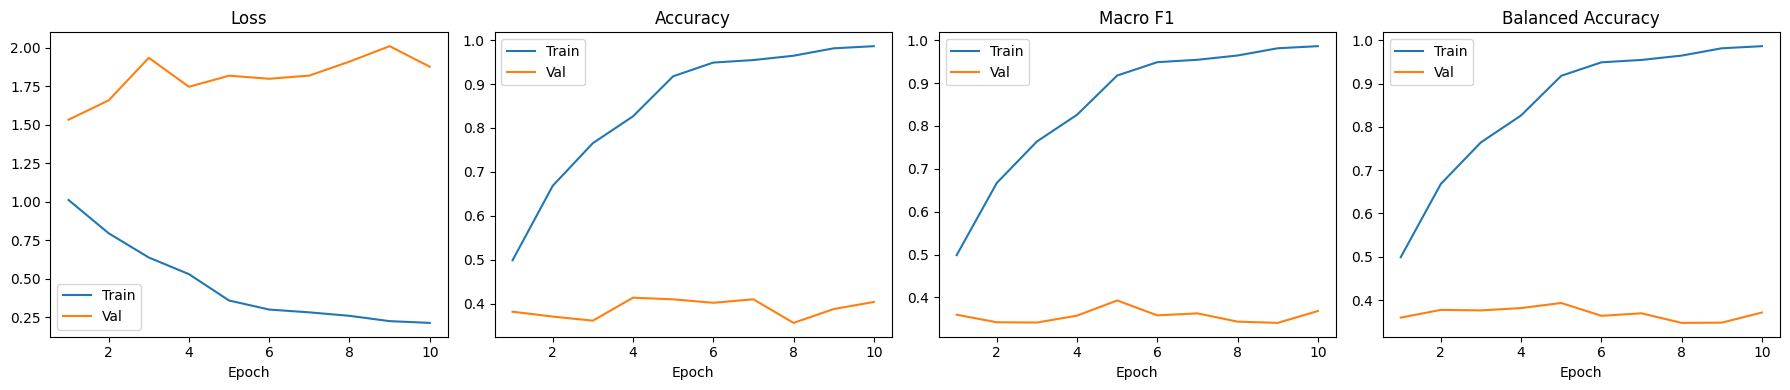

In [16]:
# =========================
# 16) Curves
# =========================
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 4, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 4, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 4, 3)
    plt.plot(epochs, history["train_macro_f1"], label="Train")
    plt.plot(epochs, history["val_macro_f1"], label="Val")
    plt.title("Macro F1")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 4, 4)
    plt.plot(epochs, history["train_bal_acc"], label="Train")
    plt.plot(epochs, history["val_bal_acc"], label="Val")
    plt.title("Balanced Accuracy")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [17]:
# =========================
# 17) Evaluation helpers
# =========================
def show_confusion_and_report(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_logits, all_preds, all_labels = [], [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_logits.append(outputs.detach().cpu())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.numpy())

    all_logits = torch.cat(all_logits, dim=0)
    return all_logits, np.array(all_labels), np.array(all_preds)

Validation metrics: {'acc': 0.4095326237852846, 'macro_f1': 0.39282874718194866, 'balanced_acc': np.float64(0.39340249858929255)}


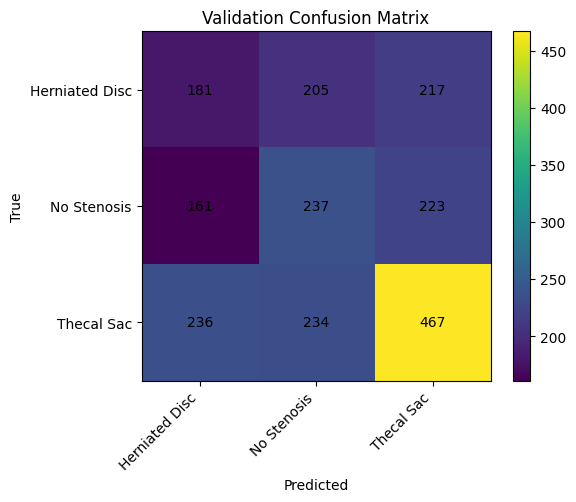

                precision    recall  f1-score   support

Herniated Disc     0.3131    0.3002    0.3065       603
   No Stenosis     0.3506    0.3816    0.3655       621
    Thecal Sac     0.5149    0.4984    0.5065       937

      accuracy                         0.4095      2161
     macro avg     0.3929    0.3934    0.3928      2161
  weighted avg     0.4114    0.4095    0.4102      2161



In [18]:
# =========================
# 18) Validation evaluation
# =========================
val_logits, y_true_val, y_pred_val = predict_loader(model, val_loader, device)

val_metrics = compute_metrics(y_true_val, y_pred_val)
print("Validation metrics:", val_metrics)

show_confusion_and_report(
    y_true_val,
    y_pred_val,
    CLASS_NAMES,
    title="Validation Confusion Matrix"
)

Test metrics: {'acc': 0.4565376186997809, 'macro_f1': 0.3578621037903434, 'balanced_acc': np.float64(0.6037781889782897)}


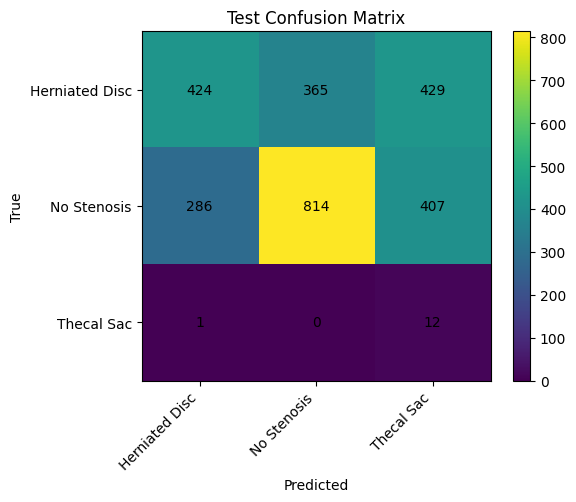

                precision    recall  f1-score   support

Herniated Disc     0.5963    0.3481    0.4396      1218
   No Stenosis     0.6904    0.5401    0.6061      1507
    Thecal Sac     0.0142    0.9231    0.0279        13

      accuracy                         0.4565      2738
     macro avg     0.4336    0.6038    0.3579      2738
  weighted avg     0.6454    0.4565    0.5293      2738



In [19]:
# =========================
# 19) Test evaluation
# =========================
test_logits, y_true_test, y_pred_test = predict_loader(model, test_loader, device)

test_metrics = compute_metrics(y_true_test, y_pred_test)
print("Test metrics:", test_metrics)

show_confusion_and_report(
    y_true_test,
    y_pred_test,
    CLASS_NAMES,
    title="Test Confusion Matrix"
)

In [20]:
# =========================
# 20) Save run summary
# =========================
run_summary = {
    "cfg": asdict(cfg),
    "class_names": CLASS_NAMES,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "test_metrics": test_metrics,
}

summary_path = os.path.join(cfg.SAVE_DIR, "run_summary.json")
pd.Series(run_summary).to_json(summary_path, indent=2)
print(f"Saved run summary -> {summary_path}")

Saved run summary -> ./outputs_lumbar_resnet34/run_summary.json


## Suggested experiment order

Start simple and compare **macro F1** and **balanced accuracy** after each change.

1. `USE_WEIGHTED_SAMPLER=True`, `LOSS_NAME="ce"`, `USE_CLASS_WEIGHTS_IN_LOSS=False`
2. same as above, but `USE_WEIGHTED_SAMPLER=False`, `USE_CLASS_WEIGHTS_IN_LOSS=True`
3. `LOSS_NAME="focal"`
4. turn on `USE_MIXUP=True`
5. try `FREEZE_BACKBONE_EPOCHS=1 or 2`

Do **not** stack every trick at once on the first run.